# Session 7: PINN for Burgers' equation

So far we have solved linear partial differential equations (PDEs) — the heat equation. In the real world, many interesting physical phenomena involve **non-linear** PDEs. [Burgers' equation](https://en.wikipedia.org/wiki/Burgers%27_equation) is a canonical benchmark for physics-informed neural networks (PINNs): it is non-linear, can develop sharp gradients (near-shock behaviour), and has been studied extensively in the original [Raissi et al. (2019)](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125) paper.

## 1. Burgers' equation

The 1D viscous Burgers' equation is:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \quad x \in [-1, 1],\; t \in [0, 1]
$$

with:
- **Initial condition**: $u(x, 0) = -\sin(\pi x)$
- **Boundary conditions**: $u(-1, t) = u(1, t) = 0$
- **Viscosity**: $\nu = 0.01/\pi$

This is the same setting as Raissi et al. (2019), making it easy to compare results.

### Physical interpretation

The equation combines:
- **Non-linear advection** ($u \cdot u_x$): the field transports itself, causing steepening and shock formation.
- **Viscous diffusion** ($\nu u_{xx}$): smooths out sharp features, preventing true discontinuities when $\nu > 0$.

For small $\nu$, a near-shock develops around $t \approx 0.3$–$0.5$, making this a genuinely challenging test case.

### PDE residual

The PINN residual at each collocation point is:

$$
r = \frac{\partial u_\theta}{\partial t} + u_\theta \frac{\partial u_\theta}{\partial x} - \nu \frac{\partial^2 u_\theta}{\partial x^2}
$$

The non-linear term $u_\theta \cdot u_x$ is handled automatically by autograd — no special treatment is needed.

## 2. Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class PINN(nn.Module):
    """MLP: input (x, t), output u. Four hidden layers of width 64."""
    def __init__(self, layers=[2, 64, 64, 64, 64, 1]):
        super().__init__()
        seq = []
        for i in range(len(layers) - 2):
            seq += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        seq.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*seq)

    def forward(self, X):
        return self.net(X)

Using device: cpu


## 3. Sampling training points

We sample collocation points uniformly inside $[-1, 1] \times [0, 1]$, boundary points at $x = \pm 1$, and initial condition (IC) points at $t = 0$.

Note that $x \in [-1, 1]$ rather than $[0, 1]$, so we map `torch.rand` → $[-1, 1]$ with $2r - 1$.

In [2]:
nu = 0.01 / np.pi
N_colloc = 20000
N_bc     = 200
N_ic     = 200

torch.manual_seed(42)

# --- Collocation: x in [-1, 1], t in [0, 1] ---
colloc_x = 2 * torch.rand(N_colloc, 1, device=device) - 1
colloc_t = torch.rand(N_colloc, 1, device=device)
colloc = torch.cat([colloc_x, colloc_t], dim=1).requires_grad_(True)

# --- Boundary conditions: u(-1, t) = u(1, t) = 0 ---
t_bc_vals = torch.rand(N_bc, device=device)
bc_left  = torch.stack([-torch.ones(N_bc, device=device), t_bc_vals], dim=1)
bc_right = torch.stack([ torch.ones(N_bc, device=device), t_bc_vals], dim=1)
bc = torch.cat([bc_left, bc_right], dim=0)

# --- Initial condition: u(x, 0) = -sin(pi*x) ---
x_ic = 2 * torch.rand(N_ic, device=device) - 1
t_ic_zeros = torch.zeros(N_ic, device=device)
ic = torch.stack([x_ic, t_ic_zeros], dim=1)
u_ic_true = -torch.sin(np.pi * x_ic).reshape(-1, 1)

## 4. PDE residual and loss

In [3]:
def burgers_residual(model, pts, nu):
    """Compute Burgers residual: u_t + u*u_x - nu*u_xx at pts."""
    u = model(pts)
    grads = torch.autograd.grad(
        u, pts,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]
    u_xx = torch.autograd.grad(
        u_x, pts,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True, retain_graph=True
    )[0][:, 0:1]
    return u_t + u * u_x - nu * u_xx   # non-linear term: u * u_x

## 5. Training

We weight the IC loss by 10 because the initial condition is the main driver of the solution and benefits from stronger enforcement.

In [4]:
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 15000
loss_history = {'total': [], 'pde': [], 'bc': [], 'ic': []}

for epoch in range(epochs):
    optimizer.zero_grad()

    residual = burgers_residual(model, colloc, nu)
    loss_pde = torch.mean(residual**2)

    loss_bc = torch.mean(model(bc)**2)

    loss_ic = torch.mean((model(ic) - u_ic_true)**2)

    loss = loss_pde + loss_bc + 10 * loss_ic
    loss.backward()
    optimizer.step()

    loss_history['total'].append(loss.item())
    loss_history['pde'].append(loss_pde.item())
    loss_history['bc'].append(loss_bc.item())
    loss_history['ic'].append(loss_ic.item())

    if epoch % 3000 == 0:
        print(f"Epoch {epoch:6d} | Total: {loss.item():.2e} | "
              f"PDE: {loss_pde.item():.2e} | BC: {loss_bc.item():.2e} | IC: {loss_ic.item():.2e}")

Epoch      0 | Total: 5.76e+00 | PDE: 5.31e-04 | BC: 1.06e-02 | IC: 5.75e-01
Epoch   3000 | Total: 7.88e-03 | PDE: 6.34e-03 | BC: 5.33e-05 | IC: 1.48e-04
Epoch   6000 | Total: 9.60e-04 | PDE: 7.57e-04 | BC: 8.93e-06 | IC: 1.94e-05
Epoch   9000 | Total: 3.13e-03 | PDE: 8.53e-04 | BC: 4.01e-04 | IC: 1.88e-04
Epoch  12000 | Total: 5.82e-04 | PDE: 4.77e-04 | BC: 6.99e-06 | IC: 9.86e-06


## 6. Results

### 6.1 Space-time solution

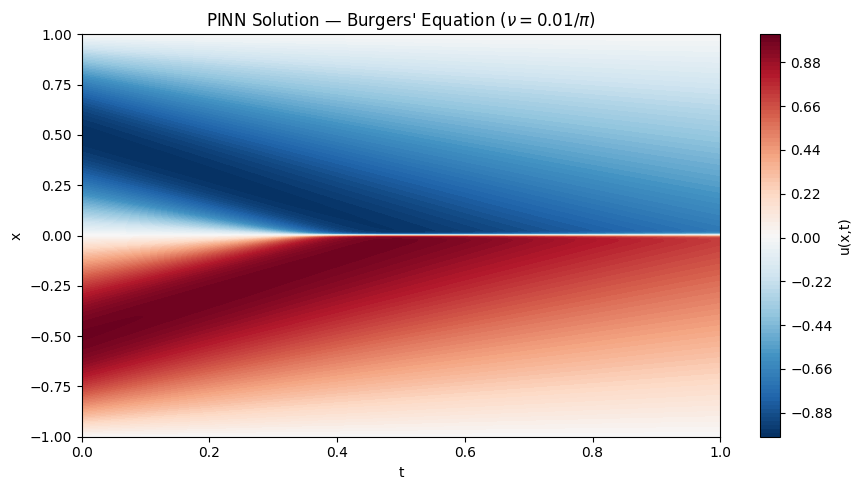

In [5]:
with torch.no_grad():
    Nx, Nt = 400, 200
    x_grid = torch.linspace(-1, 1, Nx)
    t_grid = torch.linspace(0, 1, Nt)
    X, T = torch.meshgrid(x_grid, t_grid, indexing='ij')
    XT = torch.stack([X.flatten(), T.flatten()], dim=1).to(device)
    u_pred = model(XT).cpu().numpy().reshape(Nx, Nt)

fig, ax = plt.subplots(figsize=(9, 5))
c = ax.contourf(T.numpy(), X.numpy(), u_pred, levels=100, cmap='RdBu_r')
plt.colorbar(c, ax=ax, label='u(x,t)')
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.set_title("PINN Solution — Burgers' Equation ($\\nu = 0.01/\\pi$)")
plt.tight_layout()
plt.show()

The characteristic steepening near $x = 0$ and the eventual near-shock around $t \approx 0.5$–$0.8$ are clearly visible.

### 6.2 Snapshots at selected times

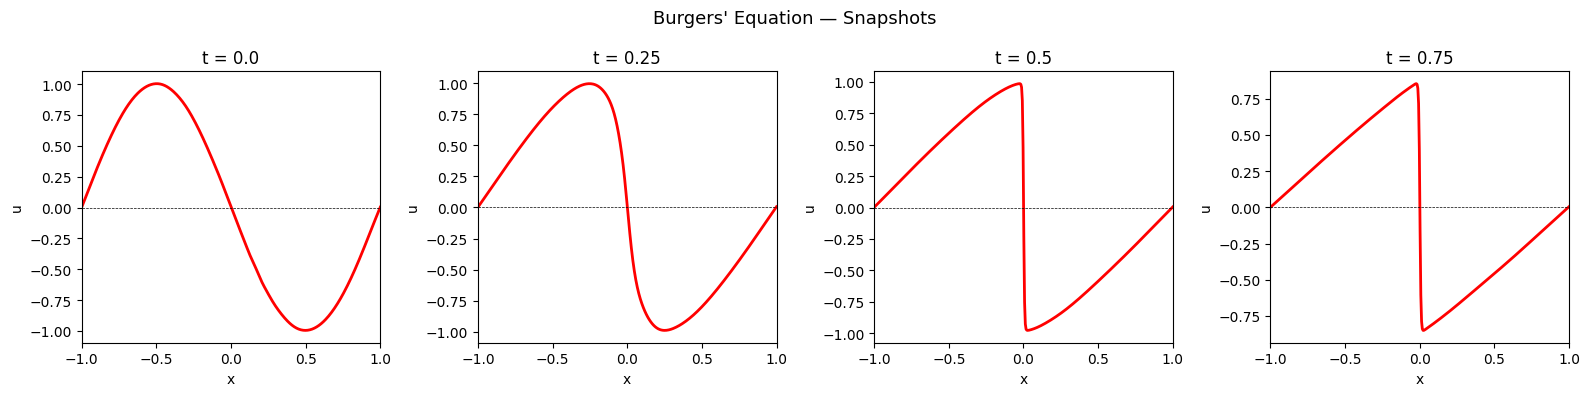

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, t_val in zip(axes, [0.0, 0.25, 0.5, 0.75]):
    x_line = torch.linspace(-1, 1, 400).reshape(-1, 1)
    t_line = torch.full_like(x_line, t_val)
    xt_line = torch.cat([x_line, t_line], dim=1).to(device)
    with torch.no_grad():
        u_snap = model(xt_line).cpu().numpy().flatten()

    ax.plot(x_line.numpy(), u_snap, 'r-', lw=2)
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_xlim(-1, 1)
    ax.axhline(0, color='k', lw=0.5, ls='--')

plt.suptitle("Burgers' Equation — Snapshots", fontsize=13)
plt.tight_layout()
plt.show()

### 6.3 Loss history

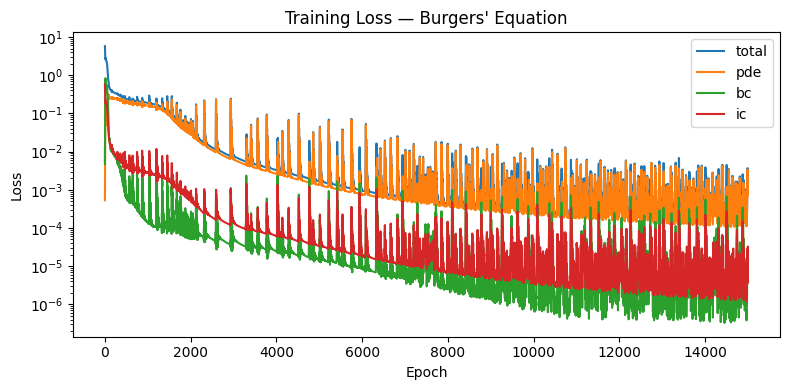

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for key, vals in loss_history.items():
    ax.semilogy(vals, label=key)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss — Burgers\' Equation')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary 

We have extended PINNs to a non-linear PDE, demonstrating the method's flexibility:
- The PDE residual is computed in exactly the same way as for linear PDEs — autograd handles the non-linearity automatically.
- The IC weight of 10 is a simple loss-balancing trick; more sophisticated approaches exist.
- Near-shock regions require more collocation points and/or adaptive sampling for high accuracy.

**[Session 8](Session8.ipynb)** tackles two advanced topics:
1. **Inverse problems** — inferring the unknown viscosity $\nu$ from noisy data while simultaneously solving the PDE.
2. **Loss balancing** — systematic strategies for choosing loss weights.
3. **2D Poisson equation** — extending PINNs to a 2D spatial domain.

**Reading**: Raissi et al. (2019) Section 3 (data-driven solutions) and Section 4 (data-driven discovery of PDEs).

## Exercises

1. **Lower viscosity**: reduce $\nu$ to $0.001/\pi$ (ten times smaller). The near-shock becomes much sharper. Observe how the PINN struggles — does the loss decrease more slowly and does the solution smear the shock? Increase the number of collocation points near $x = 0$, $t \approx 0.5$ by adding 2,000 uniformly distributed points in the box $[-0.3, 0.3] \times [0.3, 0.7]$ and compare the result.

2. **Alternative initial condition**: replace $u(x, 0) = -\sin(\pi x)$ with $u(x, 0) = -0.5\sin(\pi x) - 0.5\sin(2\pi x)$. Retrain with the same architecture and report how the near-shock location and formation time change.

3. **Periodic boundary conditions**: modify the problem domain to $x \in [-1, 1]$ with periodic boundary conditions $u(-1, t) = u(1, t)$ and $u_x(-1, t) = u_x(1, t)$. Add a periodic BC loss term and verify that the PINN enforces periodicity at $t = 0.5$.

4. **Adaptive IC weighting**: the Session 7 code uses a fixed IC weight of 10. Instead, implement a simple adaptive scheme: every 2,000 epochs, compute the ratio $\mathcal{L}_{\text{PDE}} / \mathcal{L}_{\text{IC}}$ and double the IC weight if it exceeds 10. Compare the final loss history with the fixed-weight baseline.